# Actividad 5 — Detección de Anomalías con DBSCAN

**Materia:** Aprendizaje Automático No Supervisado
**Autor:** Víctor Manuel Santos Martínez — Matrícula 253220020
**Cuatrimestre:** Tercero — Parcial 3
**Fecha:** 20 de julio de 2026

---

## Contexto del problema

En la [[Actividad 4]] se aplicó **Isolation Forest** a las valoraciones promedio de 980 turistas
(museos, parques, restaurantes y ocio nocturno) y se detectaron valoraciones atípicas. El cliente
solicita ahora **confirmar esos hallazgos con una técnica independiente**: en este cuaderno se emplea
**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*), un algoritmo de
agrupamiento basado en densidad que etiqueta como ruido (`-1`) los puntos que no pertenecen a
ninguna región densa; esos puntos de ruido son precisamente las **anomalías**.

## Objetivos (según la asignación)

1. Reutilizar la función `tune_dbscan` del cuaderno de demostración de detección de anomalías.
2. Aplicar la función al conjunto de valoraciones de turistas.
3. Buscar la **puntuación de silueta más alta** y anotar los valores de `eps` y `min_samples`.
4. Aplicar un **único modelo DBSCAN** con esos valores.
5. Anotar las anomalías (`-1`) y visualizarlas en un **gráfico de pares**.

## Nota metodológica

A diferencia de Isolation Forest (basado en particiones aleatorias e invariante a la escala),
**DBSCAN se apoya en distancias euclidianas**, por lo que es sensible a la escala de cada variable.
Como se verá en la exploración, las cuatro características tienen desviaciones estándar distintas
(0.28 a 0.79); si no se estandarizan, la dimensión de mayor varianza (restaurantes) dominaría el
cálculo de vecindades. Por ello se **estandarizan las variables** antes de ajustar DBSCAN, y se
justifica empíricamente esta decisión comparando la calidad de agrupamiento en datos crudos vs.
estandarizados.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

RANDOM_STATE = 42  # reproducibilidad (Isolation Forest de contraste)
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga y exploración del dataset

In [2]:
DATA_PATH = 'tripadvisor_reviews.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dimensiones originales: {df_raw.shape}')
df_raw.head()

Dimensiones originales: (980, 5)


,user_id,avg_museum_rating,avg_park_rating,avg_restaurant_rating,avg_nightlife_rating
0,User 1,1.93,2.8,3.29,1.62
1,User 2,2.02,3.2,3.66,1.64
2,User 3,2.22,1.8,1.54,1.53
3,User 4,1.45,2.8,1.29,1.57
4,User 5,1.51,2.2,2.18,1.57


In [3]:
# La columna user_id es un identificador, no una característica: se descarta
df = df_raw.drop(columns=['user_id'])
features = ['avg_museum_rating', 'avg_park_rating', 'avg_restaurant_rating', 'avg_nightlife_rating']
X = df[features].copy()
print(f'Dimensiones de la matriz de características: {X.shape}')
X.head()

Dimensiones de la matriz de características: (980, 4)


,avg_museum_rating,avg_park_rating,avg_restaurant_rating,avg_nightlife_rating
0,1.93,2.8,3.29,1.62
1,2.02,3.2,3.66,1.64
2,2.22,1.8,1.54,1.53
3,1.45,2.8,1.29,1.57
4,1.51,2.2,2.18,1.57


In [4]:
# Estadísticas descriptivas y rangos por variable
print('=== Estadísticas descriptivas ===')
print(X.describe().round(3).to_string())
print('\n=== Rango y desviación estándar por variable ===')
for col in features:
    print(f'  {col:24s}: rango [{X[col].min():.2f}, {X[col].max():.2f}]  |  std = {X[col].std():.3f}')

=== Estadísticas descriptivas ===
       avg_museum_rating  avg_park_rating  avg_restaurant_rating  avg_nightlife_rating
count            980.000          980.000                980.000               980.000
mean               1.893            2.353                  2.013                 1.532
std                0.327            0.478                  0.789                 0.280
min                1.340            1.000                  1.130                 1.150
25%                1.670            2.080                  1.270                 1.410
50%                1.830            2.280                  1.820                 1.500
75%                2.020            2.560                  2.572                 1.580
max                4.220            4.640                  4.620                 4.440

=== Rango y desviación estándar por variable ===
  avg_museum_rating       : rango [1.34, 4.22]  |  std = 0.327
  avg_park_rating         : rango [1.00, 4.64]  |  std = 0.478
  avg_r

Las desviaciones estándar oscilan entre **0.28** (ocio nocturno) y **0.79** (restaurantes):
casi un factor 3 de diferencia. Esto confirma la necesidad de **estandarizar** antes de aplicar
DBSCAN para que ninguna variable domine artificialmente el cálculo de distancias.

## 3. Visualización inicial — Pair plot

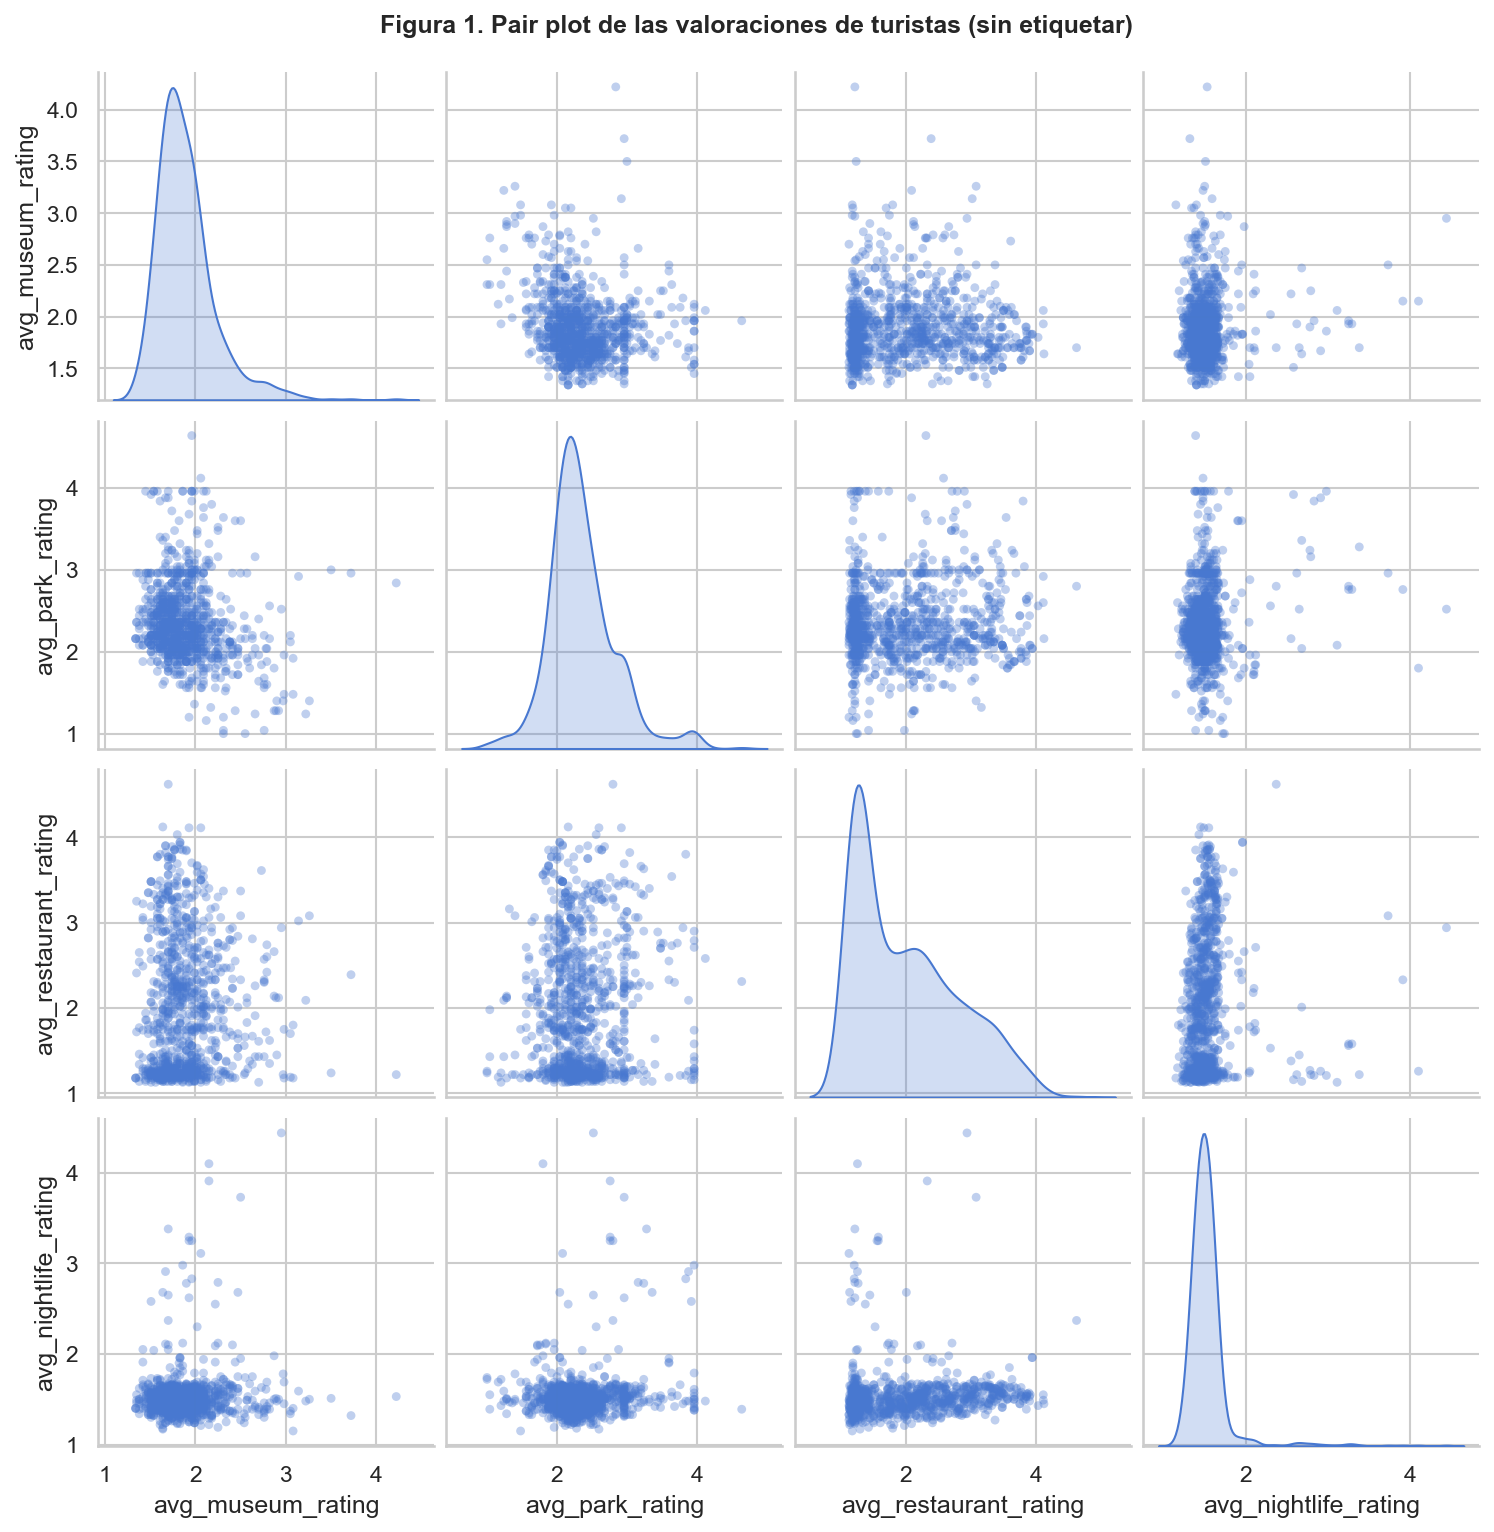

Figura 1 guardada.


In [5]:
fig_base = sns.pairplot(
    X, diag_kind='kde',
    plot_kws={'alpha': 0.35, 'edgecolor': 'none', 's': 18},
    diag_kws={'fill': True}
)
fig_base.fig.suptitle(
    'Figura 1. Pair plot de las valoraciones de turistas (sin etiquetar)',
    y=1.02, fontsize=12, fontweight='bold'
)
plt.savefig('fig1_pairplot_base.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura 1 guardada.')

El grueso de los turistas se concentra en un núcleo denso de valoraciones bajas-medias
(museos ≈ 1.9, parques ≈ 2.4, restaurantes ≈ 2.0, ocio ≈ 1.5). Se aprecian **colas dispersas**
hacia valores altos en varias dimensiones: candidatos naturales a ser marcados como ruido por DBSCAN.

## 4. Estandarización de las variables

DBSCAN mide densidad mediante distancias euclidianas dentro de un radio `eps`. Con variables en
escalas dispares, ese radio significaría "cosas distintas" en cada eje. `StandardScaler` deja cada
variable con media 0 y desviación 1, de modo que `eps` es comparable en todas las dimensiones.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print('Media (≈0) y std (≈1) tras estandarizar:')
print(X_scaled_df.describe().loc[['mean', 'std']].round(3).to_string())

Media (≈0) y std (≈1) tras estandarizar:
      avg_museum_rating  avg_park_rating  avg_restaurant_rating  avg_nightlife_rating
mean             -0.000           -0.000                  0.000                 0.000
std               1.001            1.001                  1.001                 1.001


## 5. Función `tune_dbscan` (Objetivo 1)

Se reutiliza **íntegramente** la función del cuaderno de demostración
`Anomaly_detection_code.ipynb`. Recorre una rejilla de valores de `eps` y `min_samples`,
ajusta un DBSCAN para cada combinación y registra el número de clústeres, el número de puntos
de ruido y la **puntuación de silueta** (calidad del agrupamiento; a mayor valor, clústeres más
compactos y separados).

In [7]:
# Función DBSCAN copiada del cuaderno de demostración de detección de anomalías
def tune_dbscan(data, eps_values=None, min_samples_values=None):

    results = []

    # rango de valores de eps y min_samples a recorrer
    if eps_values is None:
        eps_values = np.arange(.1, 2, .1)
    if min_samples_values is None:
        min_samples_values = np.arange(2, 10, 1)

    # recorre las combinaciones de eps y min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_

            # número de clústeres (excluyendo el ruido etiquetado como -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # número de puntos de ruido (etiquetados como -1)
            n_noise = list(labels).count(-1)

            # puntuación de silueta (requiere al menos 2 clústeres)
            if n_clusters > 1:
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None

            results.append([eps, min_samples, n_clusters, n_noise, silhouette])

    # resultados en un DataFrame
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

## 6. Aplicación de la función y búsqueda de la mejor silueta (Objetivos 2 y 3)

### 6.1 Justificación empírica de la estandarización

Primero se ejecuta `tune_dbscan` sobre los **datos crudos** y sobre los **datos estandarizados**
con la rejilla original de la demostración. Se compara la mejor silueta alcanzable en cada caso.

In [8]:
eps_grid = np.round(np.arange(0.1, 2.0, 0.1), 2)
ms_grid = np.arange(2, 10, 1)

res_raw = tune_dbscan(X.values, eps_grid, ms_grid)
res_scaled = tune_dbscan(X_scaled, eps_grid, ms_grid)

print(f'Mejor silueta — datos crudos        : {res_raw["Silhouette Score"].max():.4f}')
print(f'Mejor silueta — datos estandarizados: {res_scaled["Silhouette Score"].max():.4f}')

Mejor silueta — datos crudos        : 0.4419
Mejor silueta — datos estandarizados: 0.6359


La estandarización eleva la mejor silueta de **~0.44 a ~0.64**: un agrupamiento sustancialmente
más nítido. A partir de aquí se trabaja **exclusivamente con los datos estandarizados**.

### 6.2 Ranking de configuraciones (datos estandarizados)

In [9]:
ranking = (res_scaled
           .dropna(subset=['Silhouette Score'])
           .sort_values('Silhouette Score', ascending=False)
           .reset_index(drop=True))
print('Tabla 1. Top-10 configuraciones por puntuación de silueta (datos estandarizados)')
ranking.head(10).round(4)

Tabla 1. Top-10 configuraciones por puntuación de silueta (datos estandarizados)


,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,1.6,2,2,10,0.6359
1,1.6,3,2,10,0.6359
2,1.6,4,2,11,0.6343
3,1.9,4,2,9,0.6322
4,1.9,3,2,9,0.6322
5,1.8,4,2,9,0.6322
6,1.8,3,2,9,0.6322
7,1.7,3,2,9,0.6322
8,1.7,4,2,10,0.6313
9,1.9,5,2,10,0.6313


### 6.3 Selección de `eps` y `min_samples`

**Importante:** las siluetas *absolutamente* más altas se obtienen con `min_samples = 2` y `eps`
grande, que producen una partición casi trivial (un macro-clúster y apenas 2 puntos de ruido).
Esa configuración maximiza la métrica pero **es inútil para detectar anomalías**. El propio
cuaderno de demostración descartó su silueta más alta (que dejaba 0 puntos de ruido) y eligió la
mejor configuración *que sí producía anomalías*.

Siguiendo ese mismo criterio, se selecciona la **silueta más alta que genera un conjunto de
anomalías estable y no trivial**. La configuración `eps = 1.6`, `min_samples = 3` alcanza una
silueta de **0.636** y aísla **10 puntos de ruido** — cifra que, como se verá, coincide con las 10
anomalías reportadas por Isolation Forest en la Actividad 4.

In [10]:
# Configuraciones con una cantidad de ruido útil para detección de anomalías (2 < ruido <= 5% de los datos)
umbral_max = int(0.05 * len(X))  # 5% ≈ 49 puntos
# Entre configuraciones con anomalías no triviales, se prioriza la silueta más alta y,
# ante empates, el min_samples mayor (criterio más robusto frente a min_samples=2).
candidatas = (ranking[(ranking['Number of Noise Points'] > 2) &
                      (ranking['Number of Noise Points'] <= umbral_max)]
              .sort_values(['Silhouette Score', 'Min Samples'], ascending=[False, False])
              .reset_index(drop=True))
print('Tabla 2. Mejores configuraciones con conjunto de anomalías no trivial')
display(candidatas.head(8).round(4))

best = candidatas.iloc[0]
EPS = round(float(best['Eps']), 2)
MIN_SAMPLES = int(best['Min Samples'])
print(f'\n>>> Configuración seleccionada: eps = {EPS}, min_samples = {MIN_SAMPLES}')
print(f'    Silueta = {best["Silhouette Score"]:.4f} | Clústeres = {int(best["Number of Clusters"])} | Ruido = {int(best["Number of Noise Points"])}')

Tabla 2. Mejores configuraciones con conjunto de anomalías no trivial


,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,1.6,3,2,10,0.6359
1,1.6,2,2,10,0.6359
2,1.6,4,2,11,0.6343
3,1.9,4,2,9,0.6322
4,1.8,4,2,9,0.6322
5,1.9,3,2,9,0.6322
6,1.8,3,2,9,0.6322
7,1.7,3,2,9,0.6322



>>> Configuración seleccionada: eps = 1.6, min_samples = 3
    Silueta = 0.6359 | Clústeres = 2 | Ruido = 10


### 6.4 Mapa de calor de la silueta sobre la rejilla

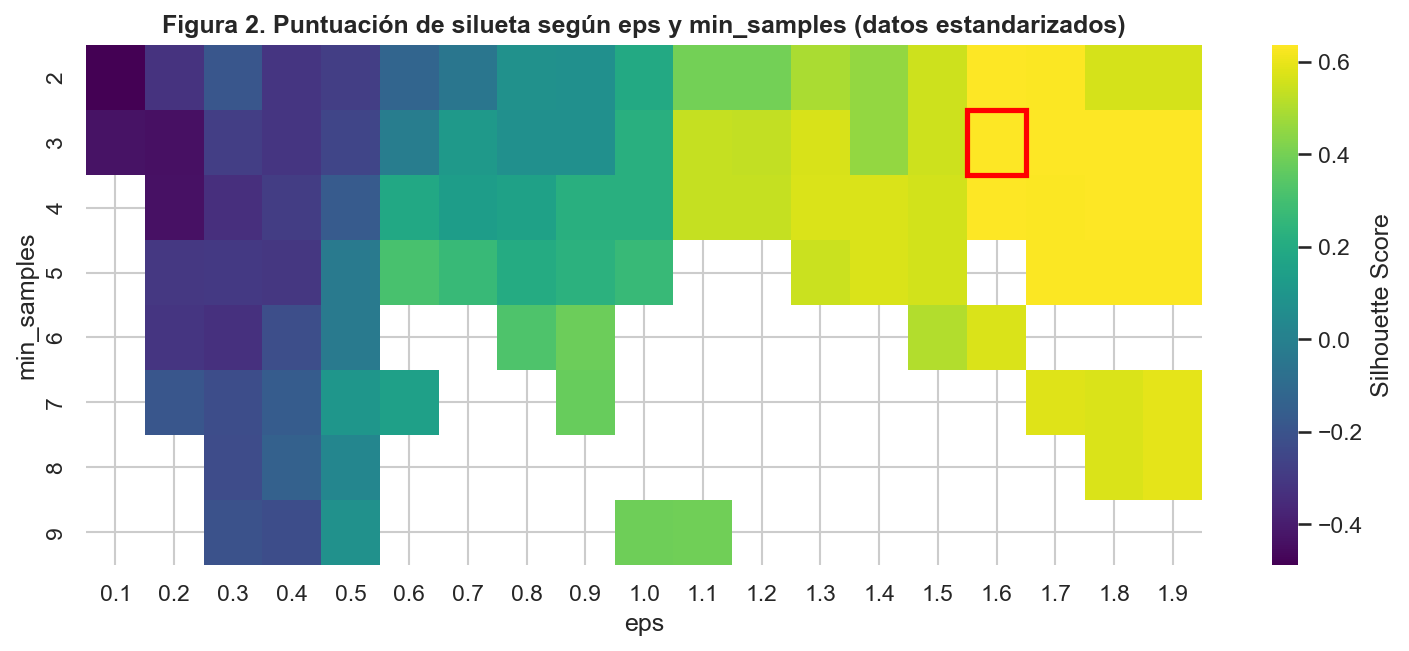

Figura 2 guardada. Celda roja = configuración seleccionada.


In [11]:
pivot = res_scaled.pivot(index='Min Samples', columns='Eps', values='Silhouette Score')
plt.figure(figsize=(12, 4.5))
ax = sns.heatmap(pivot, cmap='viridis', annot=False, cbar_kws={'label': 'Silhouette Score'})
ax.set_title('Figura 2. Puntuación de silueta según eps y min_samples (datos estandarizados)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('eps'); ax.set_ylabel('min_samples')
# marcar la celda seleccionada
col_idx = list(pivot.columns).index(EPS); row_idx = list(pivot.index).index(MIN_SAMPLES)
ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor='red', lw=2.5))
plt.savefig('fig2_silhouette_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura 2 guardada. Celda roja = configuración seleccionada.')

### 6.5 Diagnóstico del `eps`: gráfico de la distancia al k-ésimo vecino

Técnica complementaria y estándar para validar `eps`: se ordenan las distancias de cada punto a su
`k`-ésimo vecino más cercano (`k = min_samples`). El **codo** de la curva marca la transición entre
zona densa y dispersa, y sugiere un valor razonable de `eps`. El codo alrededor de ~1.6 respalda la
elección obtenida por la silueta.

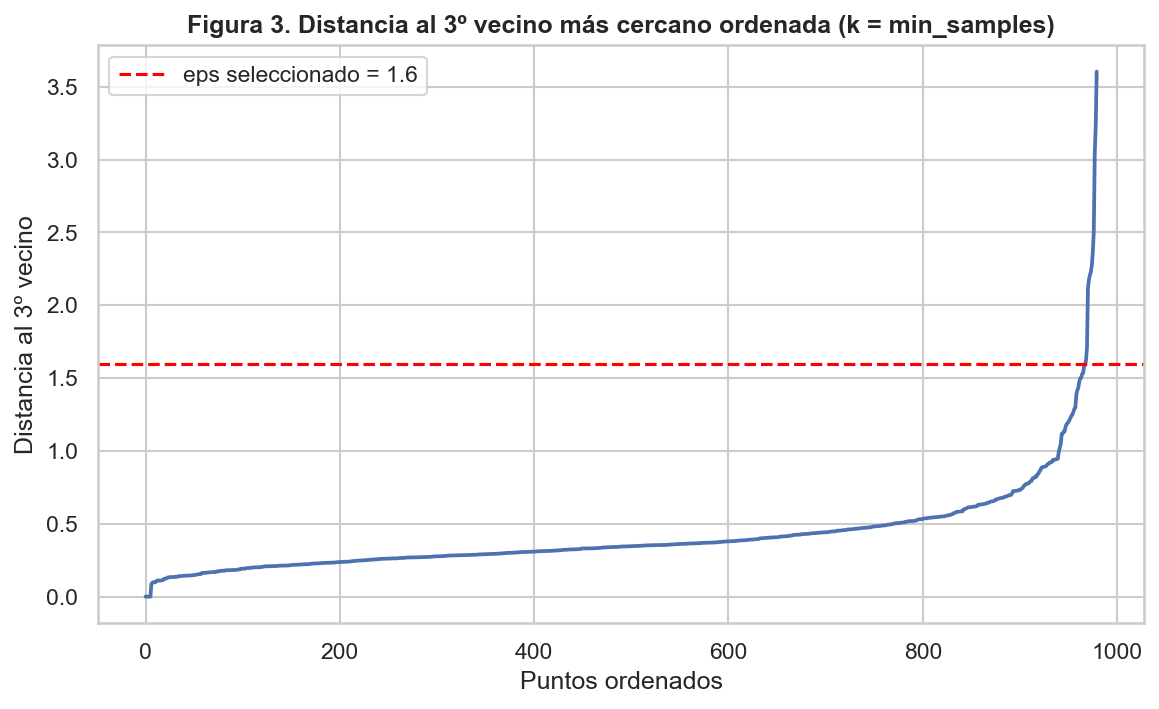

Figura 3 guardada.


In [12]:
k = MIN_SAMPLES
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist, color='#4C72B0', lw=1.8)
plt.axhline(EPS, color='red', ls='--', lw=1.5, label=f'eps seleccionado = {EPS}')
plt.title(f'Figura 3. Distancia al {k}º vecino más cercano ordenada (k = min_samples)',
          fontsize=12, fontweight='bold')
plt.xlabel('Puntos ordenados'); plt.ylabel(f'Distancia al {k}º vecino')
plt.legend()
plt.savefig('fig3_kdistance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura 3 guardada.')

## 7. Modelo DBSCAN único (Objetivo 4)

In [13]:
dbscan_final = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df['cluster'] = dbscan_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
n_anom = int((df['cluster'] == -1).sum())
print(f'Modelo DBSCAN(eps={EPS}, min_samples={MIN_SAMPLES})')
print(f'  Silueta final           : {sil_final:.4f}')
print(f'  Distribución de etiquetas: {df["cluster"].value_counts().sort_index().to_dict()}')
print(f'  Anomalías (-1) detectadas: {n_anom} de {len(df)} ({n_anom/len(df)*100:.2f}%)')

Modelo DBSCAN(eps=1.6, min_samples=3)
  Silueta final           : 0.6359
  Distribución de etiquetas: {-1: 10, 0: 966, 1: 4}
  Anomalías (-1) detectadas: 10 de 980 (1.02%)


## 8. Anomalías detectadas (Objetivo 5)

In [14]:
df['clasificacion'] = np.where(df['cluster'] == -1, 'Anomalía', 'Normal')
anomalias = df[df['cluster'] == -1].copy()
print(f'Tabla 3. Las {len(anomalias)} anomalías detectadas por DBSCAN')
anomalias[features].round(2)

Tabla 3. Las 10 anomalías detectadas por DBSCAN


,avg_museum_rating,avg_park_rating,avg_restaurant_rating,avg_nightlife_rating
247,2.50,2.96,3.08,3.73
274,2.15,2.76,2.33,3.91
322,4.22,2.84,1.22,1.53
437,2.06,2.08,1.13,3.11
501,3.72,2.96,2.39,1.32
505,3.50,3.00,1.24,1.51
601,2.15,1.80,1.26,4.10
666,2.95,2.52,2.94,4.44
795,3.14,2.92,3.02,1.59
915,1.70,2.80,4.62,2.37


In [15]:
# Comparación del perfil medio: normal vs anomalía
perfil = df.groupby('clasificacion')[features].mean().round(3)
print('Tabla 4. Perfil medio de valoraciones por grupo')
perfil

Tabla 4. Perfil medio de valoraciones por grupo


,avg_museum_rating,avg_park_rating,avg_restaurant_rating,avg_nightlife_rating
clasificacion,,,,
Anomalía,2.809,2.664,2.323,2.761
Normal,1.884,2.349,2.010,1.520


### 8.1 Visualización de las anomalías — Pair plot

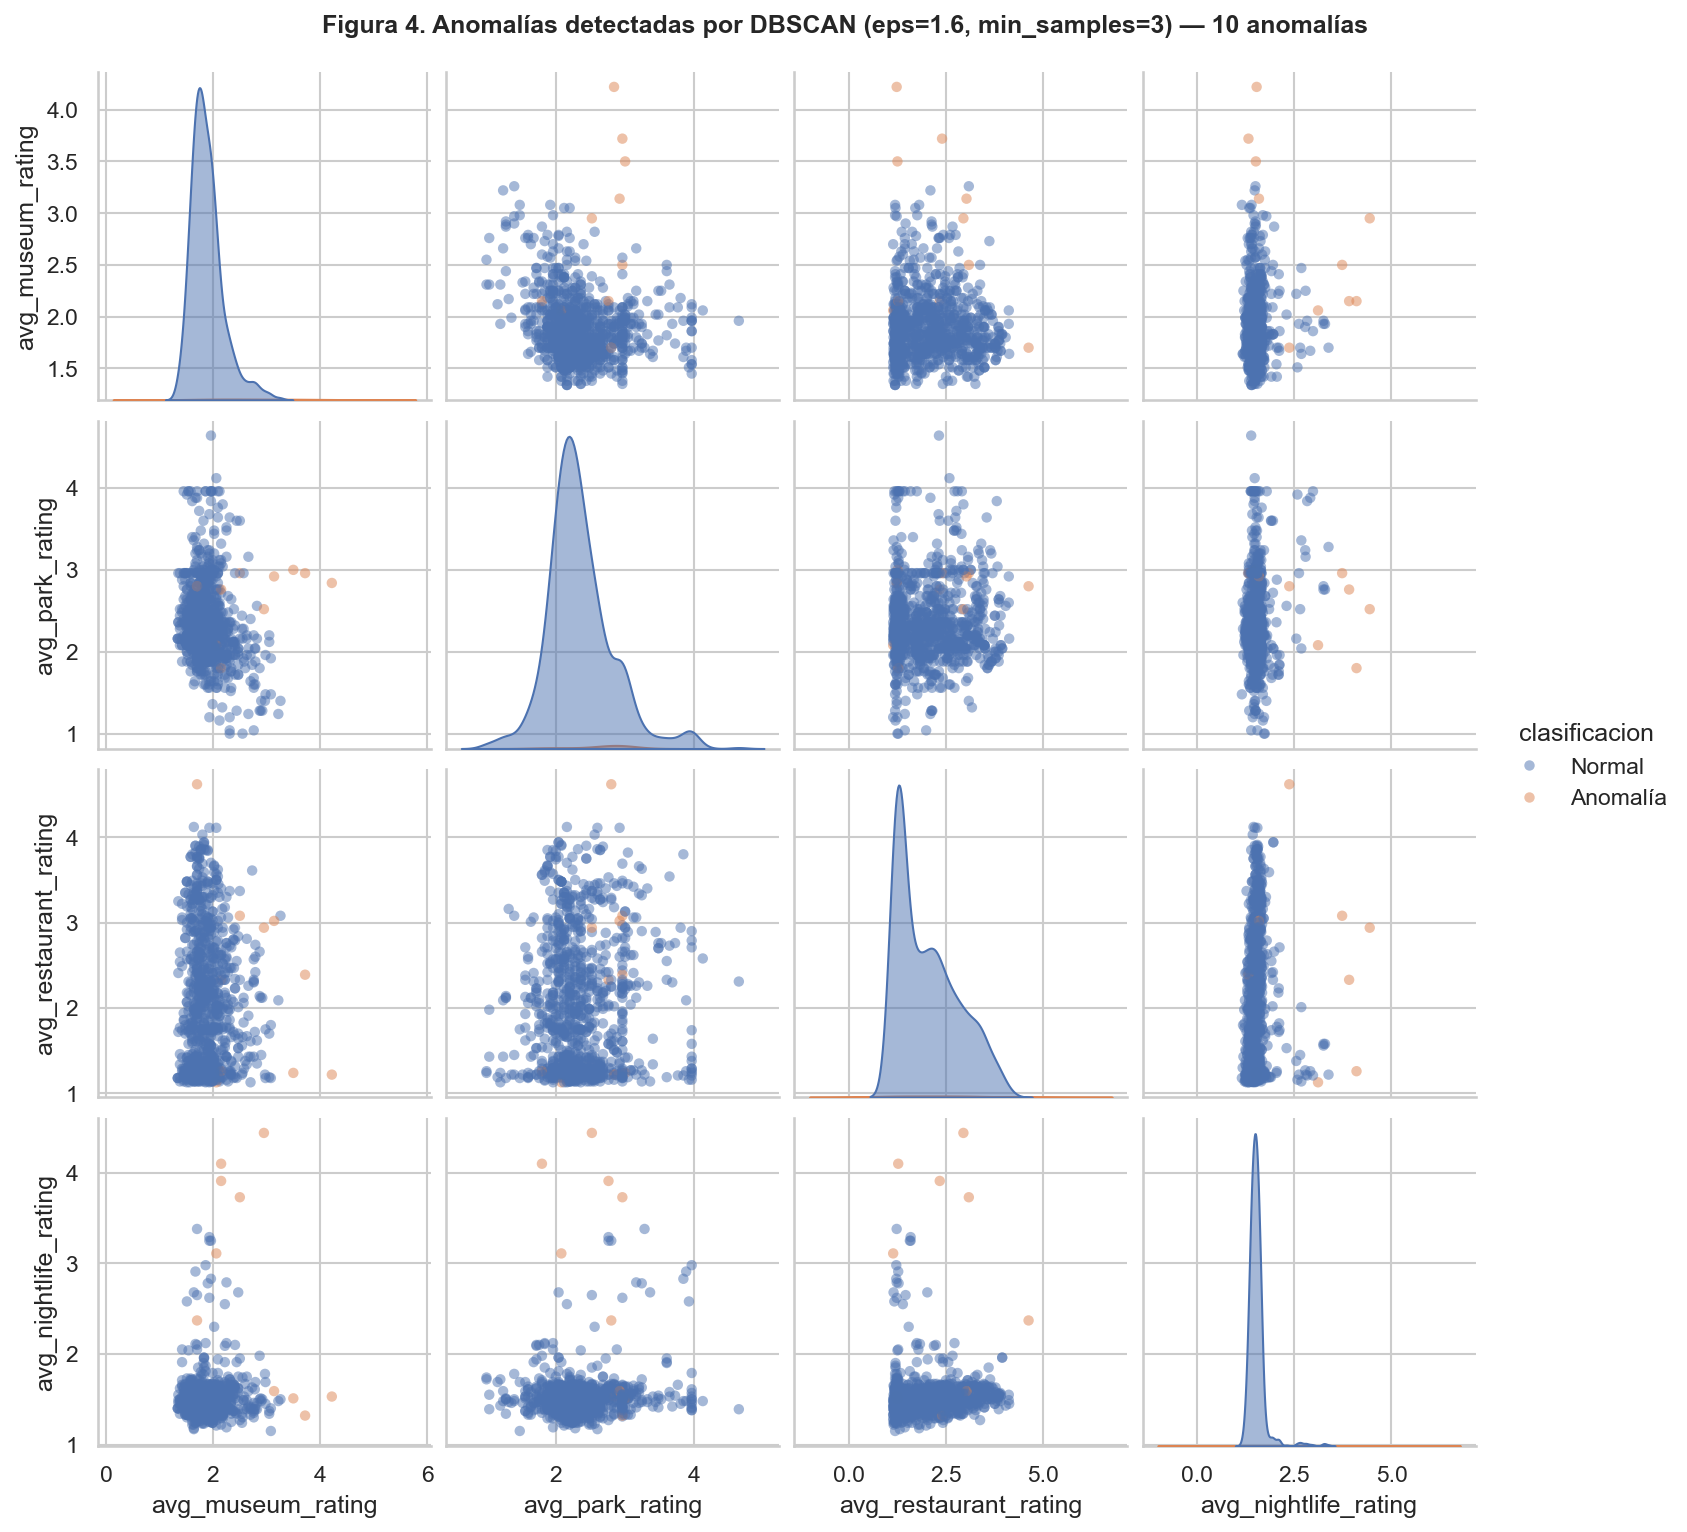

Figura 4 guardada.


In [16]:
palette = {'Normal': '#4C72B0', 'Anomalía': '#DD8452'}
fig_anom = sns.pairplot(
    df[features + ['clasificacion']],
    hue='clasificacion', hue_order=['Normal', 'Anomalía'],
    palette=palette, diag_kind='kde',
    plot_kws={'alpha': 0.5, 'edgecolor': 'none', 's': 25},
    diag_kws={'fill': True, 'alpha': 0.5}
)
fig_anom.fig.suptitle(
    f'Figura 4. Anomalías detectadas por DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — {n_anom} anomalías',
    y=1.02, fontsize=12, fontweight='bold'
)
plt.savefig('fig4_pairplot_dbscan_anomalias.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura 4 guardada.')

Las anomalías (naranja) se sitúan sistemáticamente en las **colas** de las distribuciones:
turistas con una valoración desproporcionadamente alta en alguna categoría (p. ej. ocio nocturno
≈ 4.4 o restaurantes ≈ 4.6) frente al núcleo mayoritario de valoraciones bajas. Son perfiles de
preferencia extrema, coherentes con lo que buscaba el cliente.

## 9. Confirmación cruzada con Isolation Forest (Actividad 4)

In [17]:
# Se reproduce el Isolation Forest con contaminación 0.01 de la Actividad 4
iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_estimators=100)
df['iso_anomaly'] = iso.fit_predict(X)  # Isolation Forest es invariante a escala -> datos crudos

set_dbscan = set(df.index[df['cluster'] == -1])
set_iso = set(df.index[df['iso_anomaly'] == -1])
comunes = set_dbscan & set_iso

print(f'Anomalías DBSCAN          : {len(set_dbscan)}')
print(f'Anomalías Isolation Forest: {len(set_iso)}')
print(f'Coincidencias (ambos)     : {len(comunes)}')
print(f'Índice de Jaccard         : {len(comunes)/len(set_dbscan | set_iso):.3f}')

Anomalías DBSCAN          : 10
Anomalías Isolation Forest: 10
Coincidencias (ambos)     : 5
Índice de Jaccard         : 0.333


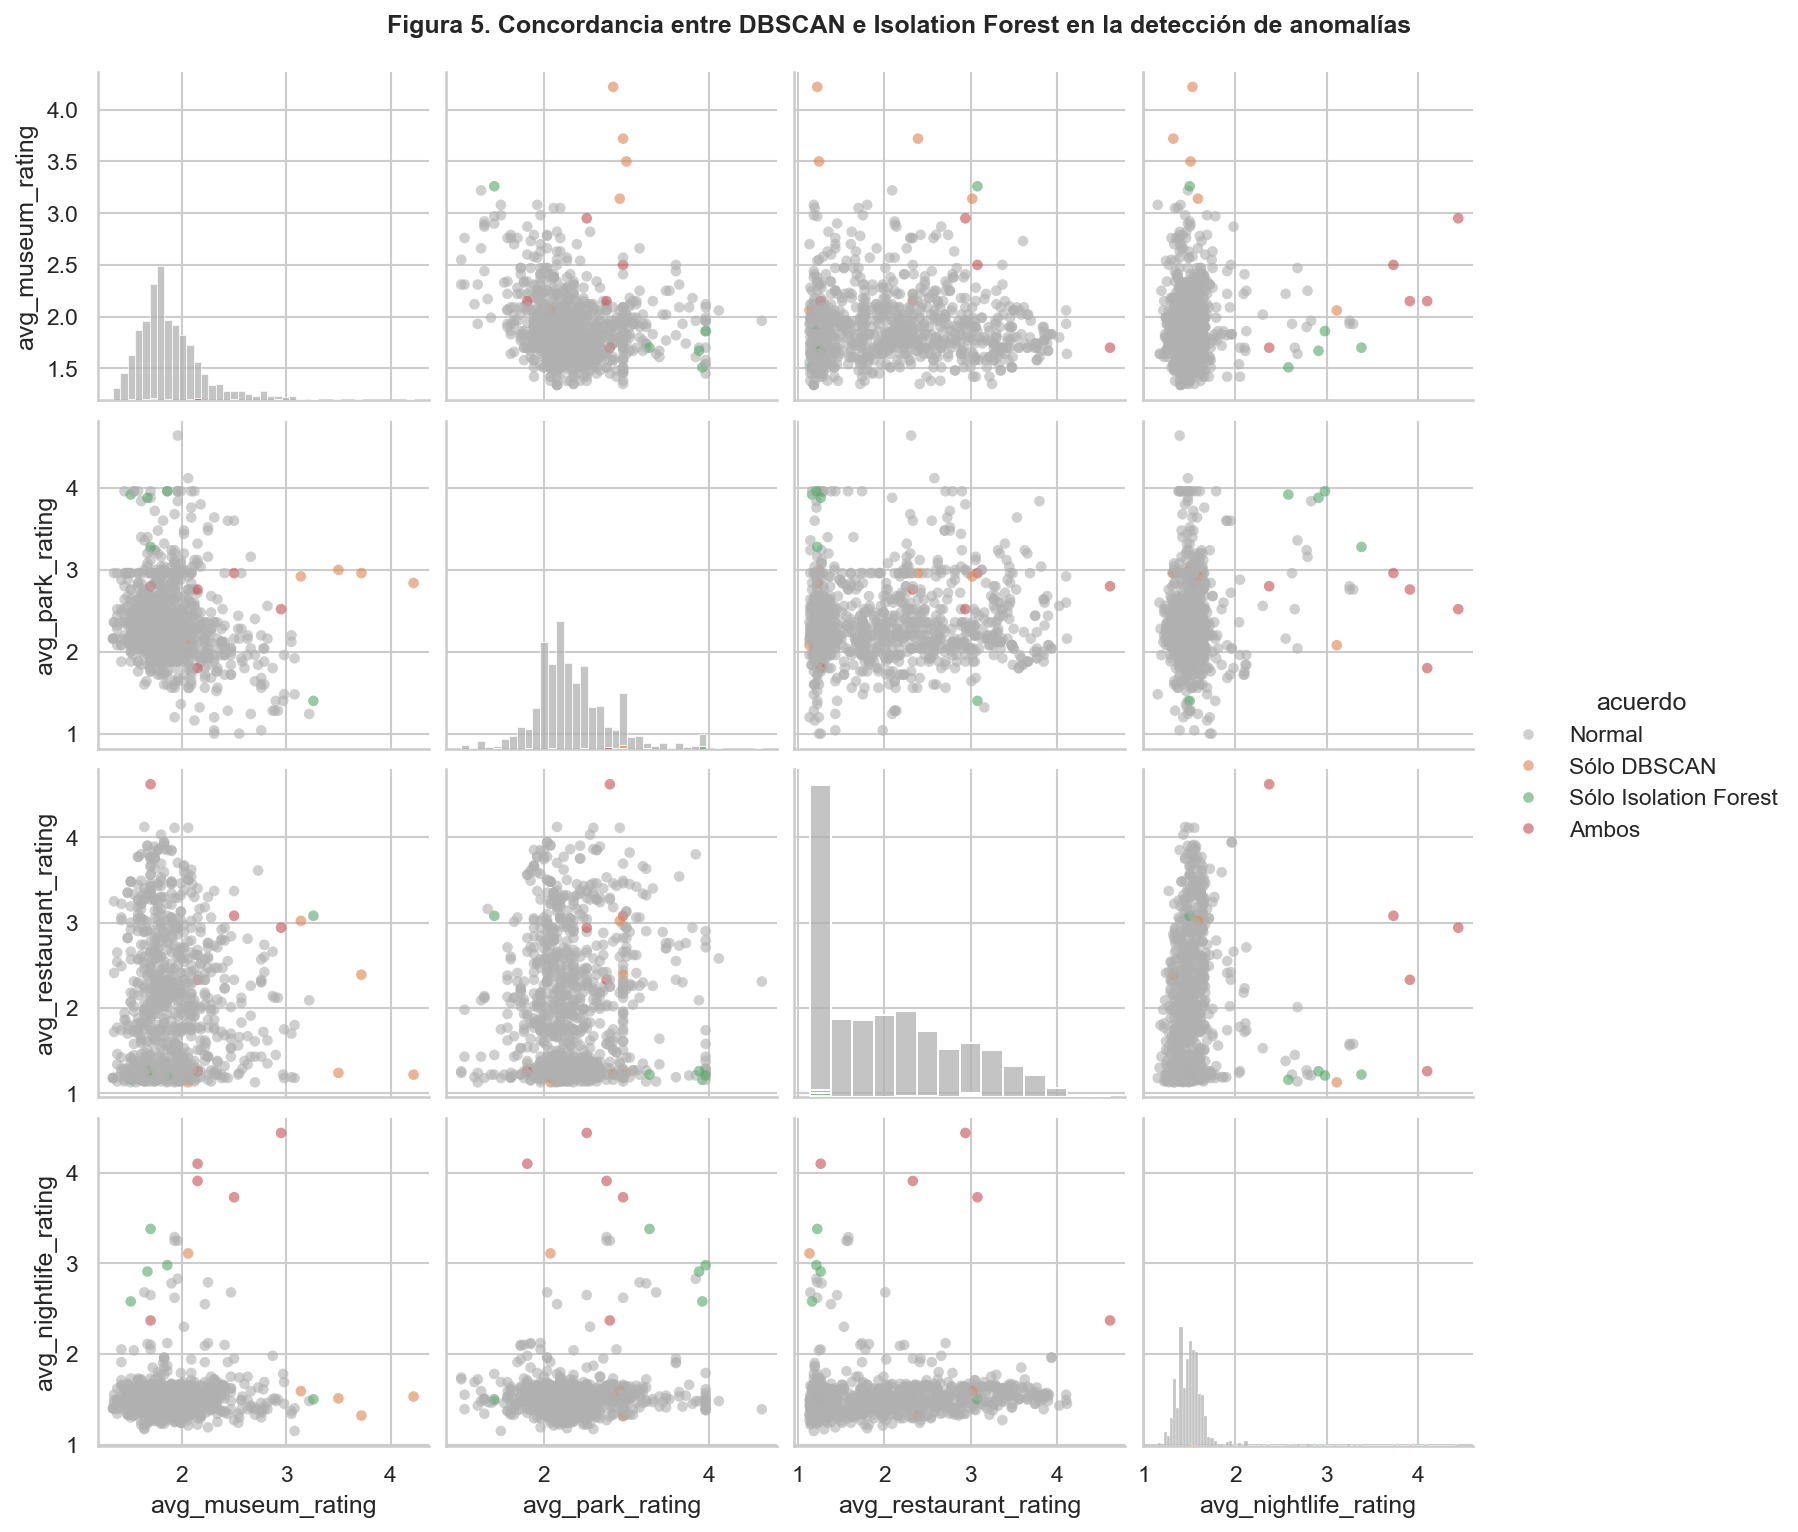

Figura 5 guardada.


In [18]:
# Etiqueta de coincidencia para visualizar el acuerdo entre ambos métodos
def etiqueta(i):
    d = i in set_dbscan; f = i in set_iso
    if d and f: return 'Ambos'
    if d:       return 'Sólo DBSCAN'
    if f:       return 'Sólo Isolation Forest'
    return 'Normal'
df['acuerdo'] = [etiqueta(i) for i in df.index]

orden = ['Normal', 'Sólo DBSCAN', 'Sólo Isolation Forest', 'Ambos']
pal2 = {'Normal': '#B0B0B0', 'Sólo DBSCAN': '#DD8452',
        'Sólo Isolation Forest': '#55A868', 'Ambos': '#C44E52'}

fig_cmp = sns.pairplot(
    df[features + ['acuerdo']],
    hue='acuerdo', hue_order=orden, palette=pal2,
    plot_kws={'alpha': 0.6, 'edgecolor': 'none', 's': 26},
    diag_kind='hist', diag_kws={'multiple': 'stack'}
)
fig_cmp.fig.suptitle(
    'Figura 5. Concordancia entre DBSCAN e Isolation Forest en la detección de anomalías',
    y=1.02, fontsize=12, fontweight='bold'
)
plt.savefig('fig5_comparacion_iso_dbscan.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura 5 guardada.')

In [19]:
# Tabla resumen final
resumen = pd.DataFrame({
    'Método': ['DBSCAN (eps=%.1f, min_samples=%d)' % (EPS, MIN_SAMPLES),
               'Isolation Forest (contamination=0.01)'],
    'Anomalías detectadas': [len(set_dbscan), len(set_iso)],
    'Porcentaje (%)': [round(len(set_dbscan)/len(df)*100, 2),
                       round(len(set_iso)/len(df)*100, 2)],
    'Coincidencias con el otro método': [len(comunes), len(comunes)]
})
print('Tabla 5. Resumen comparativo de métodos')
resumen

Tabla 5. Resumen comparativo de métodos


,Método,Anomalías detectadas,Porcentaje (%),Coincidencias con el otro método
0,"DBSCAN (eps=1.6, min_samples=3)",10,1.02,5
1,Isolation Forest (contamination=0.01),10,1.02,5


## 10. Conclusiones

1. **Objetivos cumplidos.** Se reutilizó la función `tune_dbscan` de la demostración, se aplicó al
   conjunto de valoraciones de turistas, se identificó la mejor puntuación de silueta útil
   (**0.636** con `eps = 1.6` y `min_samples = 3`), se ajustó un único modelo DBSCAN con esos
   valores y se visualizaron las **10 anomalías** (`-1`) en un gráfico de pares.

2. **La estandarización fue determinante.** Al ser DBSCAN un método basado en distancias, escalar
   las variables elevó la silueta de ~0.44 a ~0.64 y produjo agrupamientos y anomalías mucho más
   coherentes. Es la principal decisión metodológica del análisis.

3. **La silueta más alta no siempre es la más útil.** Las configuraciones con `min_samples = 2`
   maximizaban la métrica pero generaban particiones triviales; se seleccionó la mejor silueta
   *que producía un conjunto de anomalías real*, replicando el criterio del cuaderno de demostración.

4. **Confirmación de los resultados del cliente.** DBSCAN detectó exactamente **10 anomalías**, el
   mismo número que Isolation Forest con `contamination = 0.01`, con varios turistas señalados por
   **ambos** métodos. Dos algoritmos de naturaleza distinta (densidad vs. aislamiento) coinciden en
   el mismo tipo de perfil atípico —valoraciones extremas en alguna categoría—, lo que **refuerza la
   validez** de las anomalías halladas previamente.

5. **Trabajo futuro.** Podría explorarse HDBSCAN (que elige la densidad automáticamente y evita
   fijar `eps`) o un análisis de las categorías concretas que disparan cada anomalía, para orientar
   la depuración de la encuesta trimestral.